In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import pickle
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


In [2]:
df1=pd.read_csv("diabetes_prediction_dataset.csv")

In [3]:
df2=pd.read_csv("synthetic_heart_disease_dataset.csv")

In [4]:
df3=pd.read_csv("stroke_risk_dataset.csv")

In [5]:
df1.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [6]:
df1.shape

(100000, 9)

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [8]:
df1.describe

<bound method NDFrame.describe of        gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0            

In [9]:
df1.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [10]:
df1.corr(numeric_only=True)['diabetes']

age                    0.258008
hypertension           0.197823
heart_disease          0.171727
bmi                    0.214357
HbA1c_level            0.400660
blood_glucose_level    0.419558
diabetes               1.000000
Name: diabetes, dtype: float64

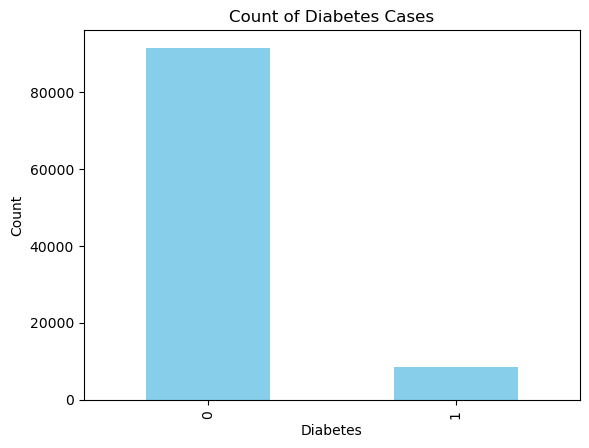

In [11]:
df1['diabetes'].value_counts().plot(kind='bar', color='skyblue')
plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.title('Count of Diabetes Cases')
plt.show()

In [12]:
df1['diabetes'].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

(array([6271., 4351., 5579., 5958., 6248., 7846., 6314., 6999., 8975.,
        7691., 7314., 7886., 5293., 4167., 9108.]),
 array([ 0.08 ,  5.408, 10.736, 16.064, 21.392, 26.72 , 32.048, 37.376,
        42.704, 48.032, 53.36 , 58.688, 64.016, 69.344, 74.672, 80.   ]),
 <BarContainer object of 15 artists>)

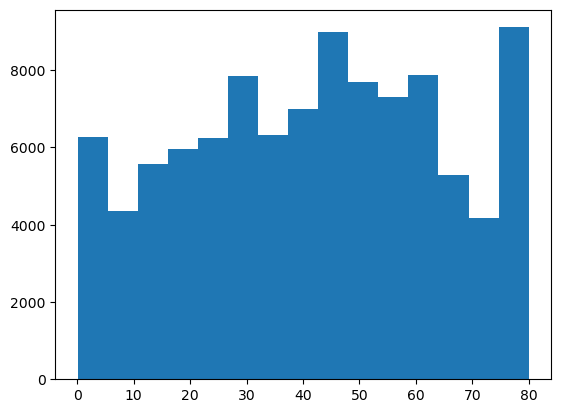

In [13]:
plt.hist(df1['age'],bins=15)

<Axes: ylabel='age'>

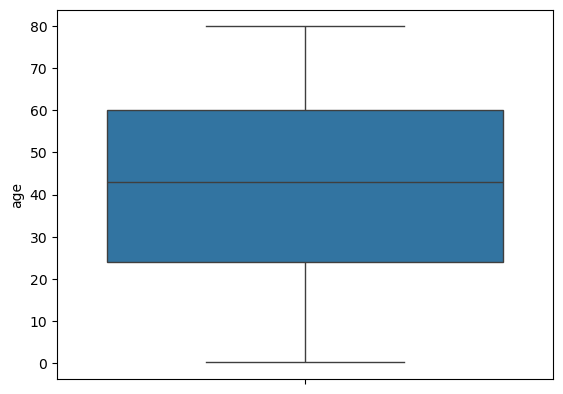

In [14]:
sns.boxplot(df1['age'])

C:\Users\JANHVI\AppData\Local\Temp\ipykernel_16660\498512504.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1['bmi'])


<Axes: xlabel='bmi', ylabel='Density'>

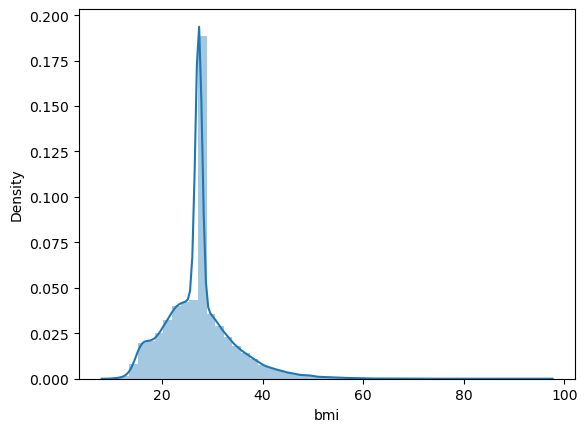

In [15]:
sns.distplot(df1['bmi'])

<Axes: xlabel='gender'>

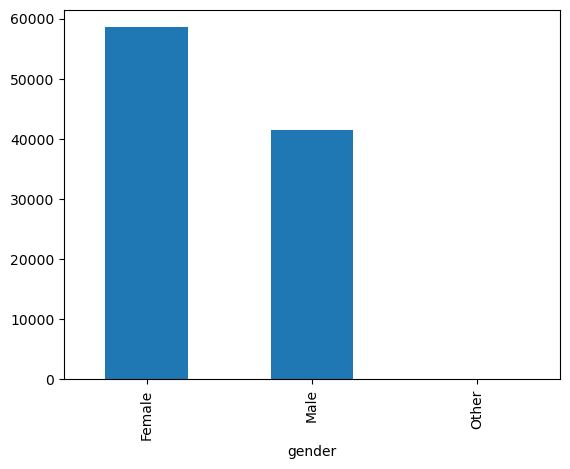

In [16]:
df1['gender'].value_counts().plot(kind='bar')

In [17]:
df1['gender'].value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

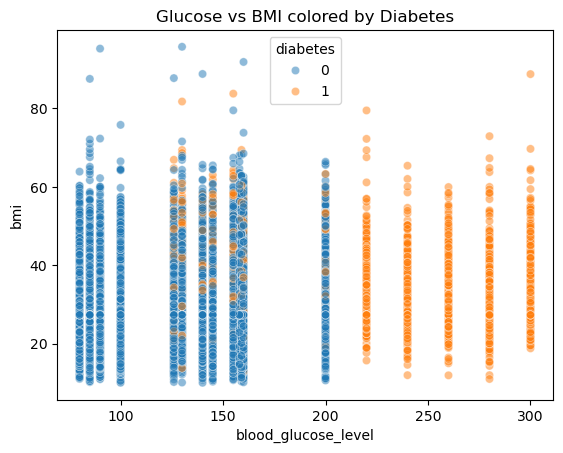

In [18]:
sns.scatterplot(x='blood_glucose_level', y='bmi', hue='diabetes', data=df1, alpha=0.5)
plt.title("Glucose vs BMI colored by Diabetes")
plt.show()

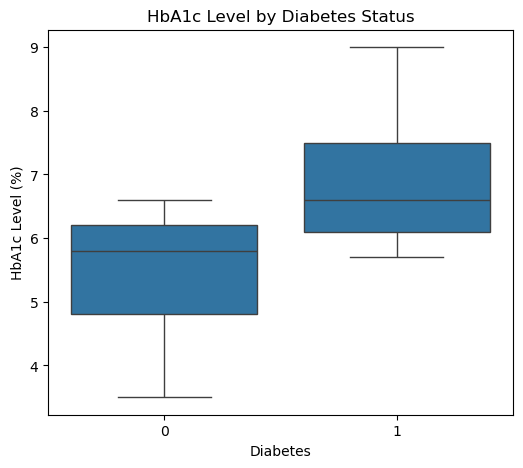

In [19]:
plt.figure(figsize=(6,5))
sns.boxplot(x='diabetes', y='HbA1c_level', data=df1)
plt.title("HbA1c Level by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("HbA1c Level (%)")
plt.show()

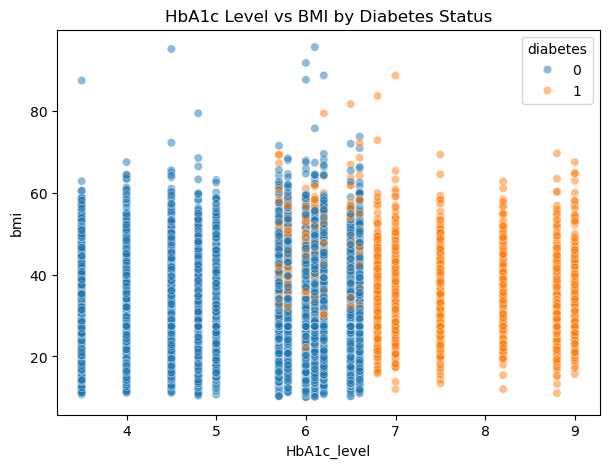

In [20]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='HbA1c_level', y='bmi', hue='diabetes', alpha=0.5, data=df1)
plt.title("HbA1c Level vs BMI by Diabetes Status")
plt.show()

C:\Users\JANHVI\AppData\Local\Temp\ipykernel_16660\371248361.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[df1['diabetes']==0]['age'])


<Axes: xlabel='age', ylabel='Density'>

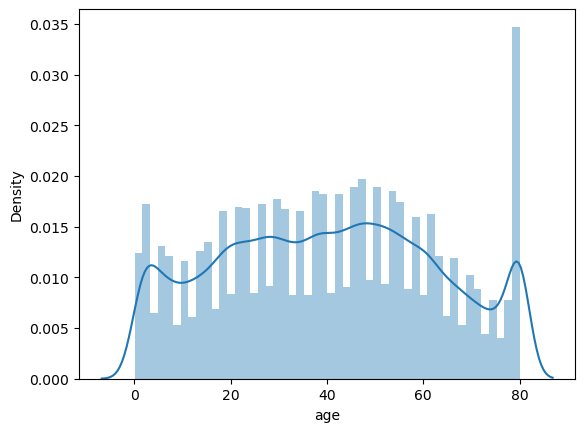

In [21]:
sns.distplot(df1[df1['diabetes']==0]['age'])

C:\Users\JANHVI\AppData\Local\Temp\ipykernel_16660\61366570.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[df1['diabetes']==1]['age'])


<Axes: xlabel='age', ylabel='Density'>

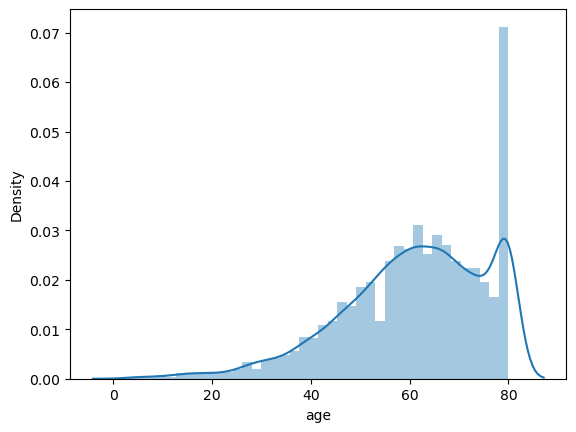

In [22]:
sns.distplot(df1[df1['diabetes']==1]['age'])

<Axes: xlabel='diabetes', ylabel='gender'>

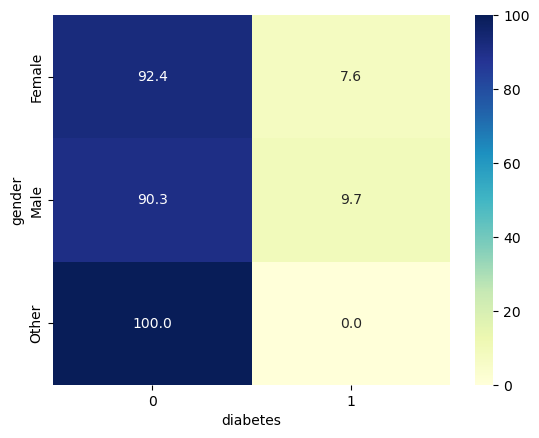

In [23]:
sns.heatmap(pd.crosstab(df1['gender'], df1['diabetes'], normalize='index')*100, annot=True, fmt='.1f', cmap='YlGnBu')

In [24]:
X = df1.drop('diabetes', axis=1)
y = df1['diabetes']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(df1.drop('diabetes', axis=1), df1['diabetes'], test_size=0.2, random_state=42)

In [26]:
le=LabelEncoder()

In [27]:
X_train['gender'] = le.fit_transform(X_train['gender'])
X_test['gender'] = le.transform(X_test['gender'])

In [28]:
oe = OrdinalEncoder()

X_train[['smoking_history']] = oe.fit_transform(X_train[['smoking_history']])
X_test[['smoking_history']] = oe.transform(X_test[['smoking_history']])

In [29]:
(X_train['smoking_history']).head(8)

75220    3.0
48955    4.0
44966    2.0
13568    5.0
92727    1.0
51349    4.0
86979    3.0
3806     4.0
Name: smoking_history, dtype: float64

In [30]:
X_train['smoking_history'].value_counts()

smoking_history
0.0    28667
4.0    28065
3.0     7510
1.0     7383
5.0     5173
2.0     3202
Name: count, dtype: int64

In [31]:
print(X_train)

       gender   age  hypertension  heart_disease  smoking_history    bmi  \
75220       1  73.0             0              0              3.0  24.77   
48955       1  80.0             0              0              4.0  24.60   
44966       0  38.0             0              0              2.0  24.33   
13568       0  26.0             0              0              5.0  18.87   
92727       0  61.0             1              0              1.0  22.11   
...       ...   ...           ...            ...              ...    ...   
6265        1  49.0             0              0              4.0  32.98   
54886       0  15.0             0              0              4.0  28.10   
76820       1  42.0             0              0              4.0  26.14   
860         0  37.0             0              0              4.0  24.96   
15795       0  23.0             0              0              4.0  27.99   

       HbA1c_level  blood_glucose_level  
75220          3.5                   80  
489

In [32]:
scaler=StandardScaler()

In [33]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

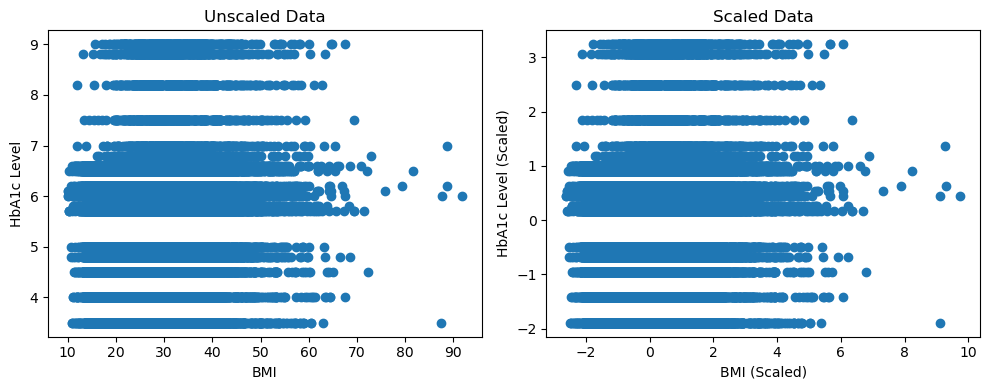

In [34]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X_train['bmi'], X_train['HbA1c_level'])
plt.title("Unscaled Data")
plt.xlabel("BMI")
plt.ylabel("HbA1c Level")

plt.subplot(1,2,2)
plt.scatter(
    X_train_scaled[:, list(X_train.columns).index('bmi')],
    X_train_scaled[:, list(X_train.columns).index('HbA1c_level')]
)
plt.title("Scaled Data")
plt.xlabel("BMI (Scaled)")
plt.ylabel("HbA1c Level (Scaled)")

plt.tight_layout()
plt.show()

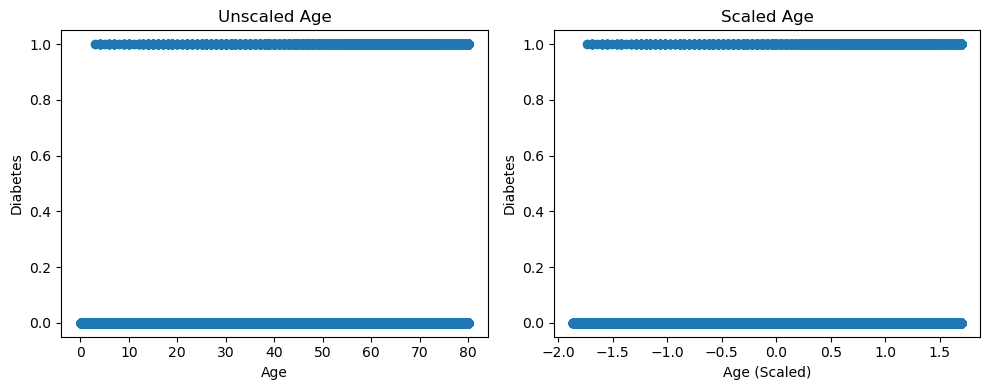

In [35]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X_train['age'], y_train)
plt.title("Unscaled Age")
plt.xlabel("Age")
plt.ylabel("Diabetes")

plt.subplot(1,2,2)
plt.scatter(
    X_train_scaled[:, list(X_train.columns).index('age')],
    y_train
)
plt.title("Scaled Age")
plt.xlabel("Age (Scaled)")
plt.ylabel("Diabetes")

plt.tight_layout()
plt.show()

In [36]:
scaled_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [37]:
non_scaled_models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

In [38]:
results = []

# scaled models
for name, model in scaled_models.items():

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })


# non scaled models
for name, model in non_scaled_models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })


results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression   0.95865   0.863749  0.612412  0.716684
1                  SVM   0.96235   0.976072  0.573185  0.722243
2                  KNN   0.96125   0.891688  0.621780  0.732666
3        Decision Tree   0.95355   0.722444  0.740632  0.731425
4        Random Forest   0.97000   0.948220  0.686183  0.796196


In [39]:
results_df.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
3,Decision Tree,0.95355,0.722444,0.740632,0.731425
4,Random Forest,0.97000,0.948220,0.686183,0.796196
2,KNN,0.96125,0.891688,0.621780,0.732666
0,Logistic Regression,0.95865,0.863749,0.612412,0.716684
1,SVM,0.96235,0.976072,0.573185,0.722243


In [40]:
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
4,Random Forest,0.97000,0.948220,0.686183,0.796196
2,KNN,0.96125,0.891688,0.621780,0.732666
3,Decision Tree,0.95355,0.722444,0.740632,0.731425
1,SVM,0.96235,0.976072,0.573185,0.722243
0,Logistic Regression,0.95865,0.863749,0.612412,0.716684


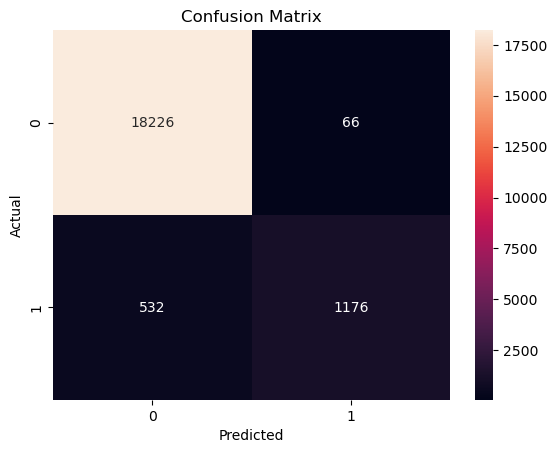

In [41]:
best_model = RandomForestClassifier()

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [42]:
rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

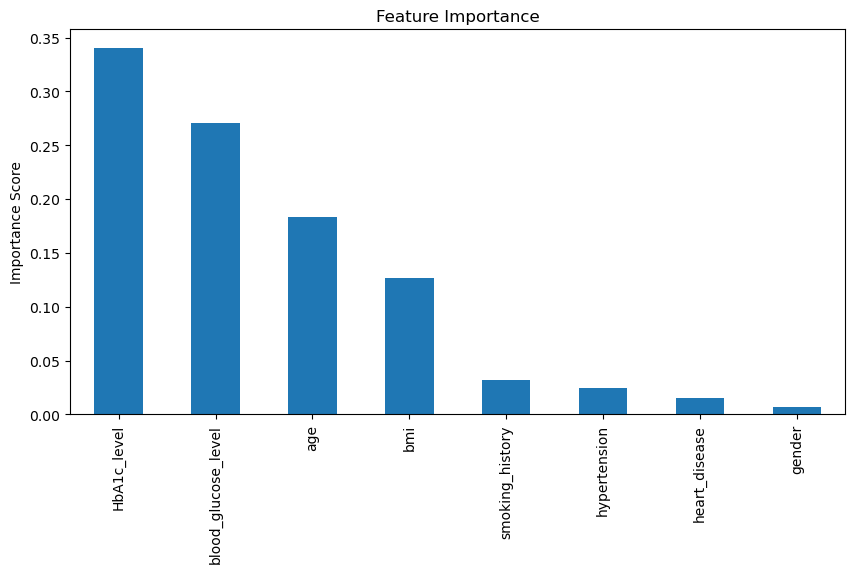

In [43]:
importances = rf.feature_importances_
features = X.columns
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

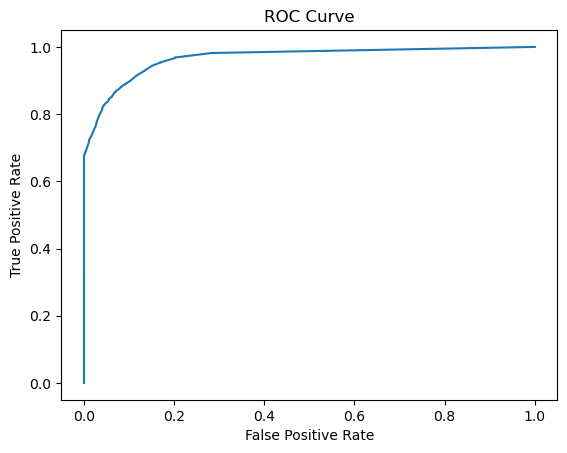

In [44]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [45]:
categorical_cols = ['gender', 'smoking_history']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough',
    force_int_remainder_cols=False
)

In [47]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier())
])

In [48]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'smoking_history'])])),
                ('model', RandomForestClassifier())])

In [49]:
test_case = pd.DataFrame({
'gender':['Male'],
'age':[65],
'hypertension':[1],
'heart_disease':[1],
'smoking_history':['current'],
'bmi':[36],
'HbA1c_level':[9],
'blood_glucose_level':[250]
})

print(pipeline.predict(test_case))

[1]


In [50]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.95      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



In [51]:
pickle.dump(pipeline, open("diabetes_pipeline.pkl","wb"))

In [52]:
#Heart Disease Prediction

In [53]:
df2.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1


In [54]:
df2['Heart_Disease'].value_counts()

Heart_Disease
0    26827
1    23173
Name: count, dtype: int64

In [55]:
df2.shape

(50000, 21)

In [56]:
df2.describe()

,Age,Weight,Height,BMI,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.46406,84.547520,174.460000,28.984284,0.299620,0.199260,0.251660,0.400500,0.099280,139.299580,89.528800,84.449560,124.493020,224.556360,0.463460
std,14.43809,20.213257,14.420379,6.367494,0.458096,0.399448,0.433971,0.490005,0.299041,23.083544,17.258063,14.491325,31.691507,43.157467,0.498668
min,30.00000,50.000000,150.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,60.000000,60.000000,70.000000,150.000000,0.000000
25%,42.00000,67.000000,162.000000,23.500000,0.000000,0.000000,0.000000,0.000000,0.000000,119.000000,75.000000,72.000000,97.000000,187.000000,0.000000
50%,54.00000,85.000000,174.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.000000,90.000000,85.000000,125.000000,225.000000,0.000000
75%,67.00000,102.000000,187.000000,34.500000,1.000000,0.000000,1.000000,1.000000,0.000000,159.000000,104.000000,97.000000,152.000000,262.000000,1.000000
max,79.00000,119.000000,199.000000,40.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,119.000000,109.000000,179.000000,299.000000,1.000000


In [57]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Weight                 50000 non-null  int64  
 3   Height                 50000 non-null  int64  
 4   BMI                    50000 non-null  float64
 5   Smoking                50000 non-null  object 
 6   Alcohol_Intake         29891 non-null  object 
 7   Physical_Activity      50000 non-null  object 
 8   Diet                   50000 non-null  object 
 9   Stress_Level           50000 non-null  object 
 10  Hypertension           50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Hyperlipidemia         50000 non-null  int64  
 13  Family_History         50000 non-null  int64  
 14  Previous_Heart_Attack  50000 non-null  int64  
 15  Sy

In [58]:
df2.isnull().sum()

Age                          0
Gender                       0
Weight                       0
Height                       0
BMI                          0
Smoking                      0
Alcohol_Intake           20109
Physical_Activity            0
Diet                         0
Stress_Level                 0
Hypertension                 0
Diabetes                     0
Hyperlipidemia               0
Family_History               0
Previous_Heart_Attack        0
Systolic_BP                  0
Diastolic_BP                 0
Heart_Rate                   0
Blood_Sugar_Fasting          0
Cholesterol_Total            0
Heart_Disease                0
dtype: int64

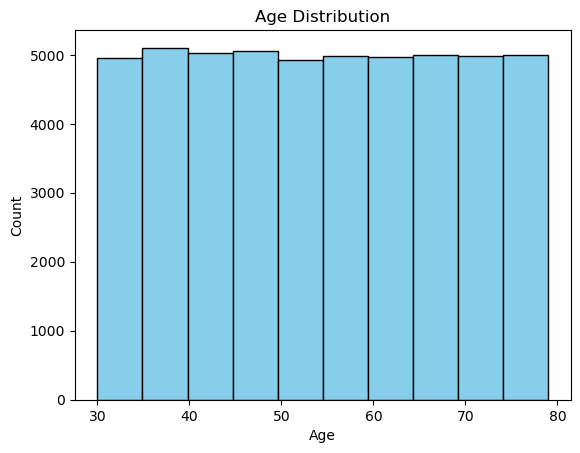

In [59]:
plt.hist(df2['Age'], bins=10, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

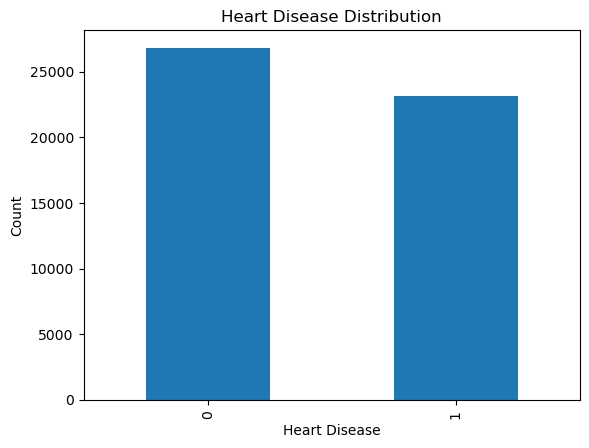

In [60]:
df2['Heart_Disease'].value_counts().plot(kind='bar')
plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.show()

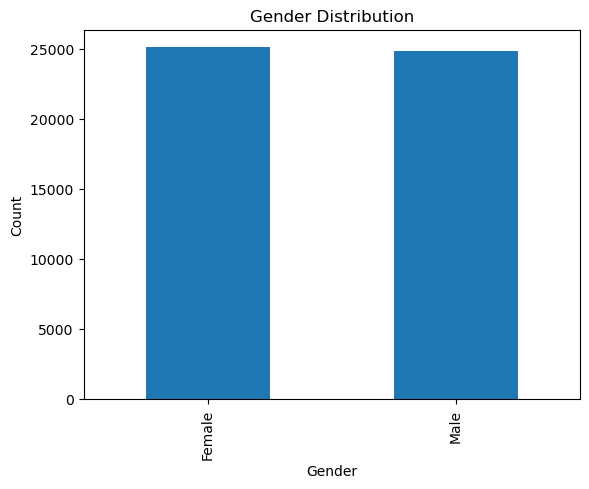

In [61]:
df2['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [62]:
df2['Gender'].value_counts()

Gender
Female    25110
Male      24890
Name: count, dtype: int64

C:\Users\JANHVI\AppData\Local\Temp\ipykernel_16660\458398406.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2['Cholesterol_Total'] )


<Axes: xlabel='Cholesterol_Total', ylabel='Density'>

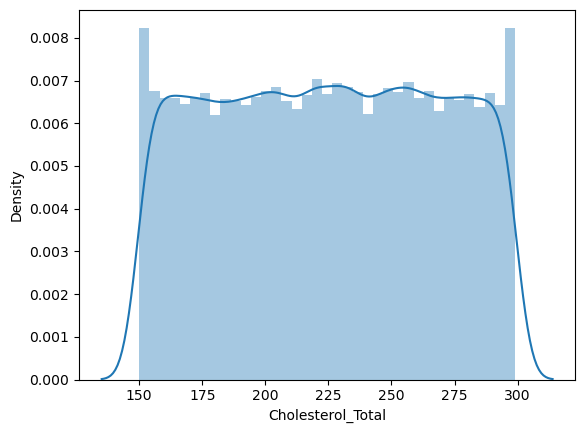

In [63]:
sns.distplot(df2['Cholesterol_Total'] )

In [64]:
categorical_cols = ['Gender','Smoking','Alcohol_Intake','Physical_Activity','Diet','Stress_Level']

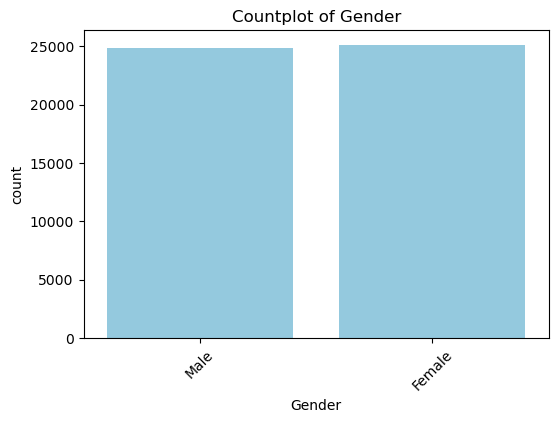

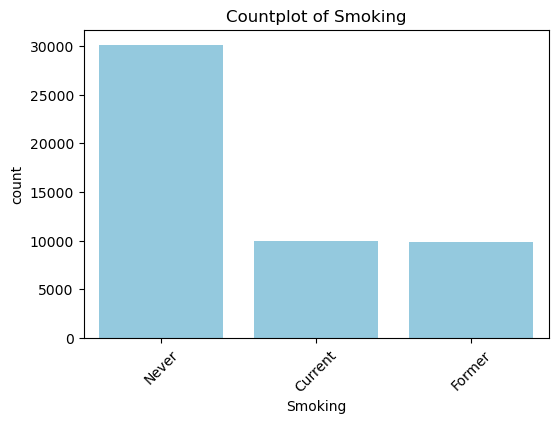

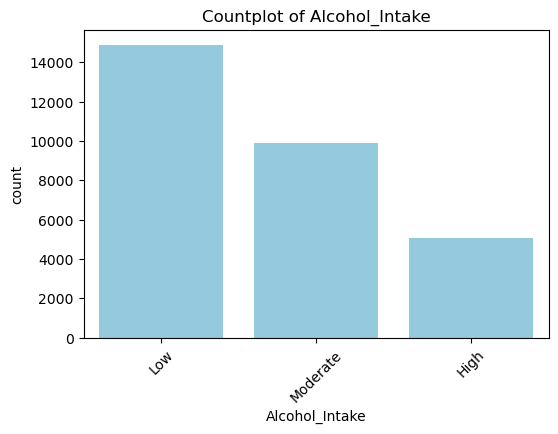

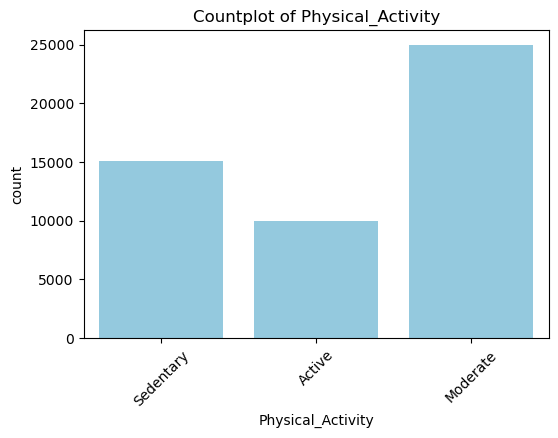

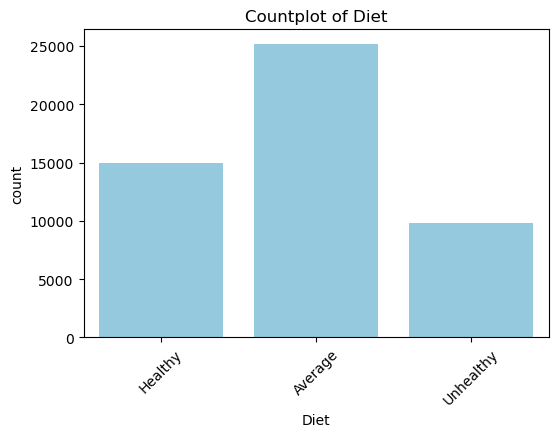

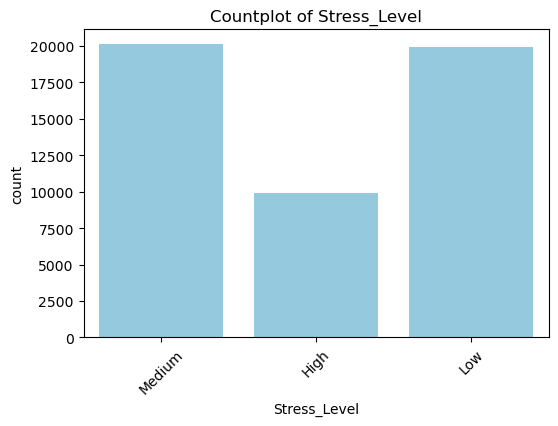

In [65]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df2, color='skyblue')  
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [66]:
numeric_cols = [
'Age','Weight','Height','BMI',
'Systolic_BP','Diastolic_BP','Heart_Rate',
'Blood_Sugar_Fasting','Cholesterol_Total'
]

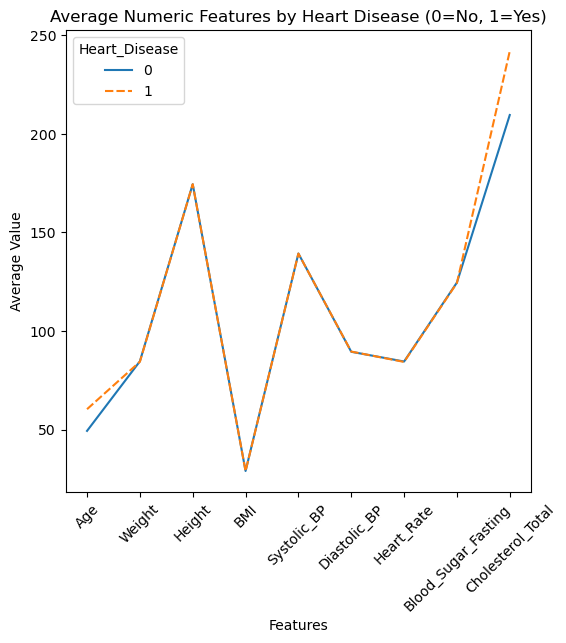

In [67]:
plt.figure(figsize=(6,6))
avg_features = df2.groupby('Heart_Disease')[numeric_cols].mean().T  # transpose to plot
sns.lineplot(data=avg_features)
plt.title('Average Numeric Features by Heart Disease (0=No, 1=Yes)')
plt.ylabel('Average Value')
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.show()

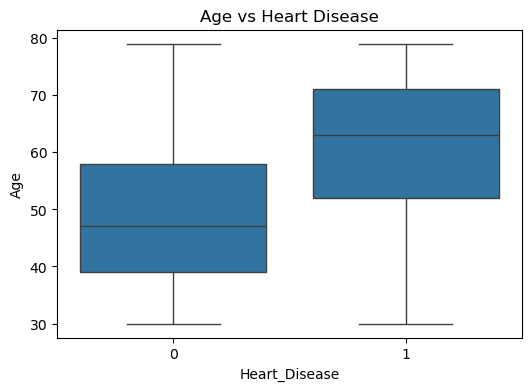

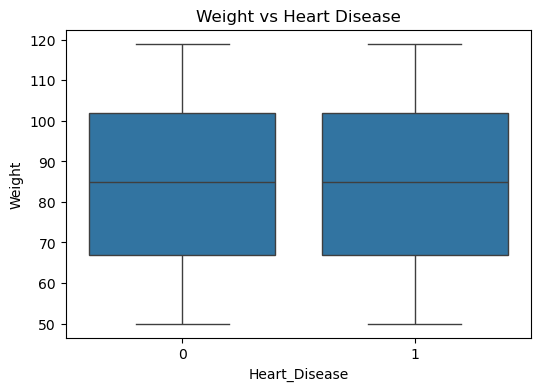

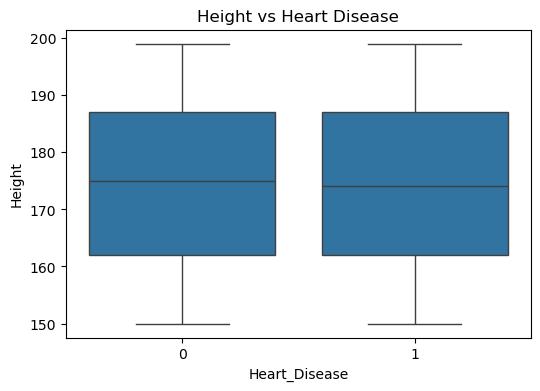

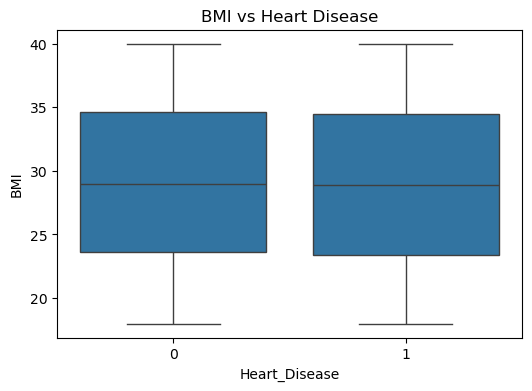

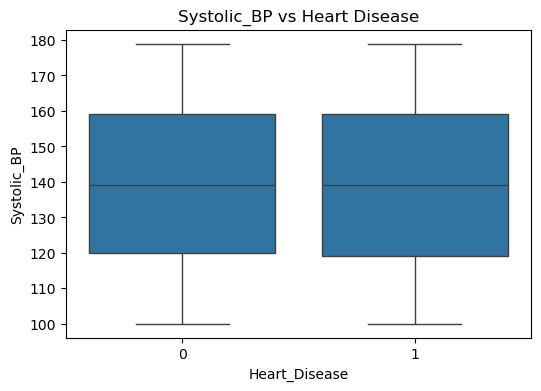

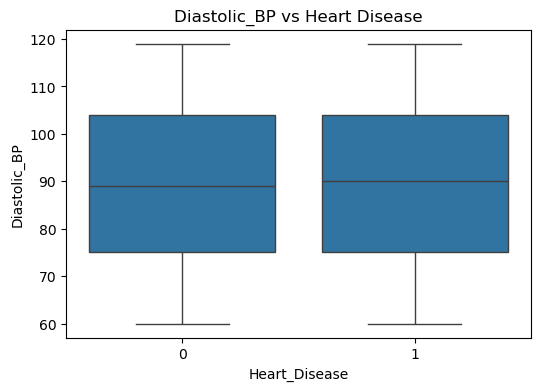

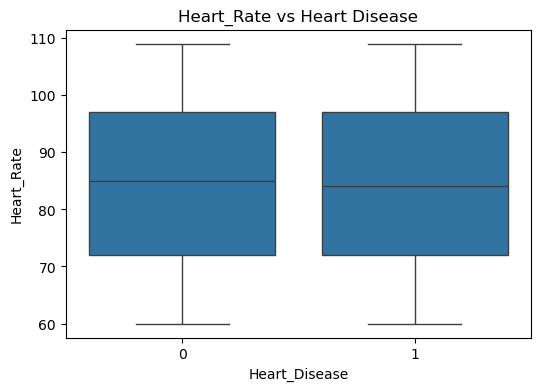

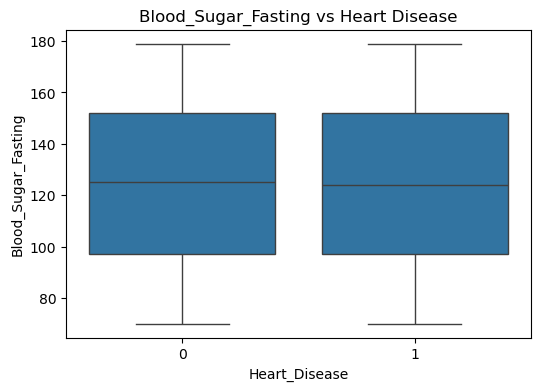

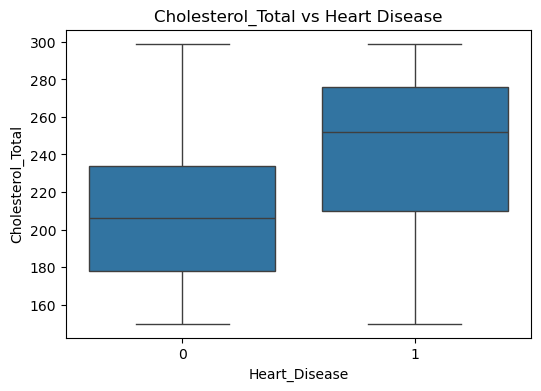

In [68]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Heart_Disease', y=col, data=df2)
    plt.title(f'{col} vs Heart Disease')
    plt.show()

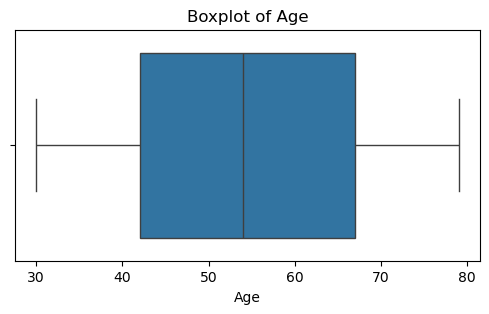

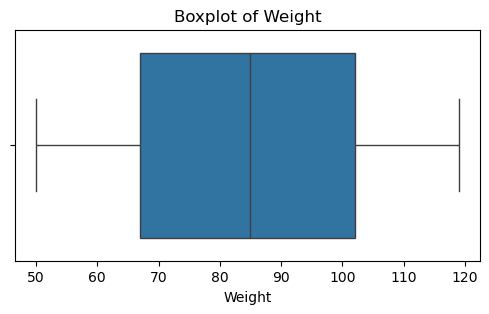

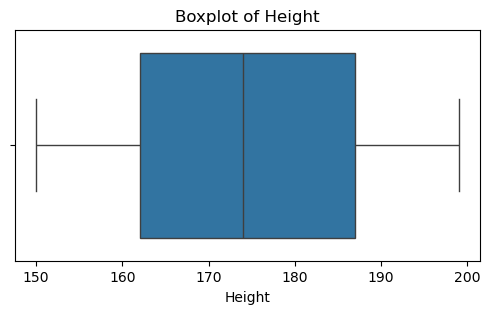

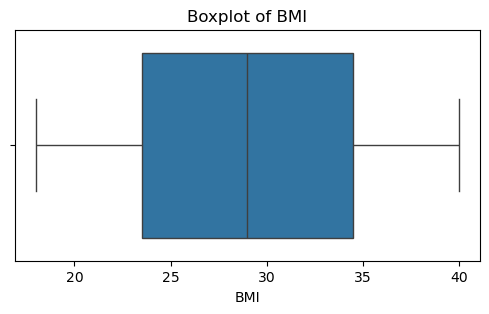

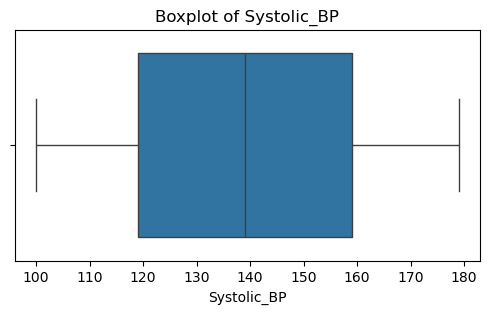

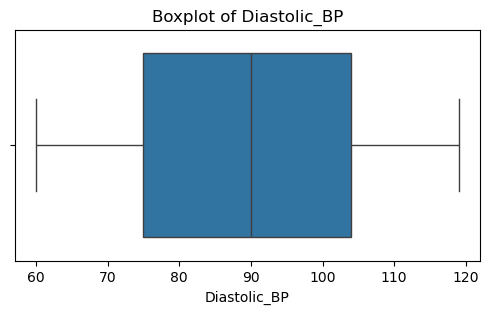

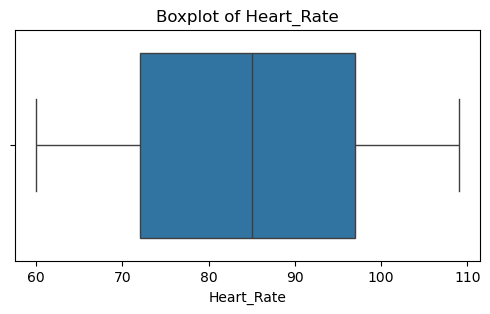

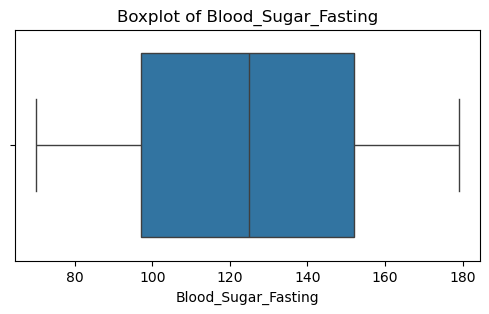

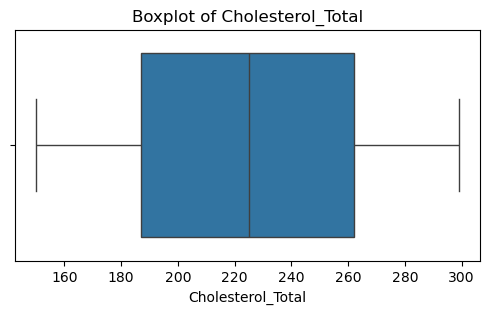

In [69]:
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df2[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [70]:
top_features = [
    'Cholesterol_Total',
    'Age',
    'Hypertension',
    'Diabetes',
    'Previous_Heart_Attack',
    'BMI',
    'Blood_Sugar_Fasting',
    'Systolic_BP'
]

In [71]:
X = df2[top_features]
y = df2['Heart_Disease']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5
    ),
    
    "KNN": KNeighborsClassifier(),
    
    "SVM": SVC(),
    
    "XGBoost": XGBClassifier(
        max_depth=5,
        n_estimators=100,
        learning_rate=0.1
    )
}

In [72]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score
1        Decision Tree    1.0000   1.000000  1.0000  1.000000
5              XGBoost    1.0000   1.000000  1.0000  1.000000
2        Random Forest    0.9996   0.999600  0.9996  0.999600
0  Logistic Regression    0.9236   0.923602  0.9236  0.923601
4                  SVM    0.7425   0.750634  0.7425  0.737209
3                  KNN    0.7084   0.707998  0.7084  0.707110


In [73]:
model = RandomForestClassifier(n_estimators=100,max_depth=5)
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

1.0


In [74]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 1, ..., 0, 1, 0])

In [75]:
y_test

5250     1
1533     0
30177    1
46041    1
30695    1
        ..
30743    0
42246    1
3534     0
45353    1
32413    0
Name: Heart_Disease, Length: 10000, dtype: int64

In [76]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [77]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5365
           1       1.00      1.00      1.00      4635

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [78]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5365    0]
 [   0 4635]]


In [79]:
print(np.unique(y_pred, return_counts=True))

(array([0, 1]), array([5365, 4635]))


In [80]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results.head(10))

   Actual  Predicted
0       1          1
1       0          0
2       1          1
3       1          1
4       1          1
5       1          1
6       1          1
7       0          0
8       0          0
9       1          1


In [81]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),   
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=5,          
        random_state=42
    ))
])

In [82]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(max_depth=5, random_state=42))])

In [83]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5365
           1       1.00      1.00      1.00      4635

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [84]:
test_input = pd.DataFrame([{
    'Age': 65,
    'Cholesterol_Total': 250,
    'Hypertension': 1,
    'Diabetes': 1,
    'Previous_Heart_Attack': 1,
    'BMI': 30,
    'Blood_Sugar_Fasting': 180,
    'Systolic_BP': 140
}])

test_input = test_input[top_features]

prediction = pipeline.predict(test_input)
probability = pipeline.predict_proba(test_input)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [1]
Probability: [[0.0027251 0.9972749]]


In [85]:
test_input = pd.DataFrame([{
    'Age': 25,
    'Cholesterol_Total': 150,
    'Hypertension': 0,
    'Diabetes': 0,
    'Previous_Heart_Attack': 0,
    'BMI': 20,
    'Blood_Sugar_Fasting': 90,
    'Systolic_BP': 110
}])

test_input = test_input[top_features]

print(pipeline.predict(test_input))
print(pipeline.predict_proba(test_input))

[0]
[[0.95191599 0.04808401]]


In [86]:
with open("heart_model.pkl", "rb") as f:
    model = pickle.load(f)
with open("features.pkl", "wb") as f:
    pickle.dump(top_features, f)
with open("features.pkl", "rb") as f:
    top_features = pickle.load(f)

test_input = pd.DataFrame([{
    'Age': 65,
    'Cholesterol_Total': 250,
    'Hypertension': 1,
    'Diabetes': 1,
    'Previous_Heart_Attack': 1,
    'BMI': 30,
    'Blood_Sugar_Fasting': 180,
    'Systolic_BP': 140
}])

test_input = test_input[top_features]

prediction = model.predict(test_input)

print("Prediction:", prediction[0])

Prediction: 1


In [ ]:
#Stroke Prediction Model

In [87]:
df3.head()

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,58.0,1
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,40.5,0
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,52.0,1
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48,60.0,1
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61,56.5,1


In [88]:
df3.shape

(70000, 18)

In [89]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Chest Pain                      70000 non-null  int64  
 1   Shortness of Breath             70000 non-null  int64  
 2   Irregular Heartbeat             70000 non-null  int64  
 3   Fatigue & Weakness              70000 non-null  int64  
 4   Dizziness                       70000 non-null  int64  
 5   Swelling (Edema)                70000 non-null  int64  
 6   Pain in Neck/Jaw/Shoulder/Back  70000 non-null  int64  
 7   Excessive Sweating              70000 non-null  int64  
 8   Persistent Cough                70000 non-null  int64  
 9   Nausea/Vomiting                 70000 non-null  int64  
 10  High Blood Pressure             70000 non-null  int64  
 11  Chest Discomfort (Activity)     70000 non-null  int64  
 12  Cold Hands/Feet                 

In [90]:
df3.describe()

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.501871,0.496471,0.498886,0.500100,0.503043,0.500557,0.499186,0.503671,0.500800,0.501943,0.500643,0.499557,0.498871,0.500686,0.499871,54.056429,55.558771,0.649200
std,0.500000,0.499991,0.500002,0.500004,0.499994,0.500003,0.500003,0.499990,0.500003,0.500000,0.500003,0.500003,0.500002,0.500003,0.500004,21.071567,14.300898,0.477224
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,5.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.000000,45.500000,0.000000
50%,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000,55.500000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,66.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,90.000000,100.000000,1.000000


In [91]:
df3.isnull().sum()

Chest Pain                        0
Shortness of Breath               0
Irregular Heartbeat               0
Fatigue & Weakness                0
Dizziness                         0
Swelling (Edema)                  0
Pain in Neck/Jaw/Shoulder/Back    0
Excessive Sweating                0
Persistent Cough                  0
Nausea/Vomiting                   0
High Blood Pressure               0
Chest Discomfort (Activity)       0
Cold Hands/Feet                   0
Snoring/Sleep Apnea               0
Anxiety/Feeling of Doom           0
Age                               0
Stroke Risk (%)                   0
At Risk (Binary)                  0
dtype: int64

In [92]:
df3.duplicated().sum()

np.int64(1021)

In [93]:
for col in df3.columns:
    if 'stroke' in col.lower():
        print("Target column is:", col)

Target column is: Stroke Risk (%)


In [94]:
df3.columns = df3.columns.str.strip().str.lower().str.replace(" ", "_").str.replace(r"[()/]", "", regex=True)

print(df3.columns)

Index(['chest_pain', 'shortness_of_breath', 'irregular_heartbeat',
       'fatigue_&_weakness', 'dizziness', 'swelling_edema',
       'pain_in_neckjawshoulderback', 'excessive_sweating', 'persistent_cough',
       'nauseavomiting', 'high_blood_pressure', 'chest_discomfort_activity',
       'cold_handsfeet', 'snoringsleep_apnea', 'anxietyfeeling_of_doom', 'age',
       'stroke_risk_%', 'at_risk_binary'],
      dtype='object')


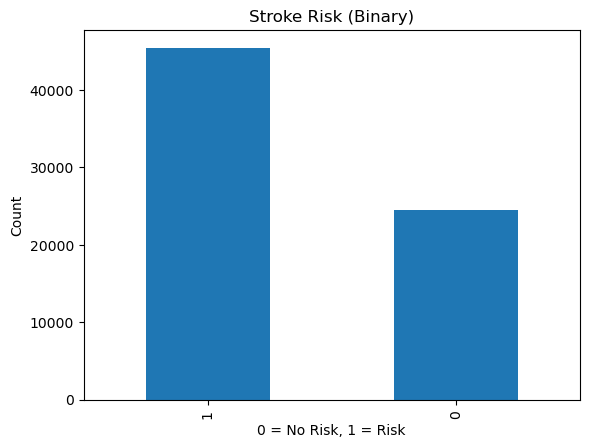

In [95]:
df3['at_risk_binary'].value_counts().plot(kind='bar')
plt.title("Stroke Risk (Binary)")
plt.xlabel("0 = No Risk, 1 = Risk")
plt.ylabel("Count")
plt.show()

In [96]:
df3['at_risk_binary'].value_counts()

at_risk_binary
1    45444
0    24556
Name: count, dtype: int64

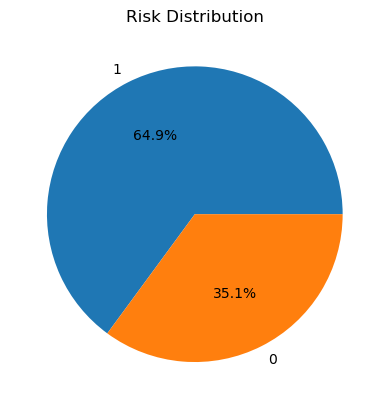

In [97]:
df3['at_risk_binary'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Risk Distribution")
plt.ylabel("")
plt.show()

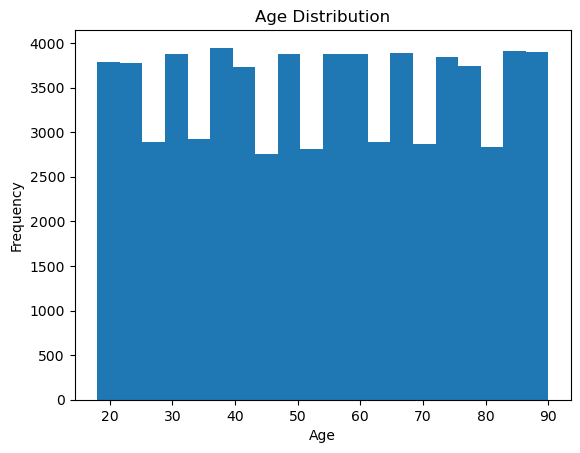

In [98]:
plt.hist(df3['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

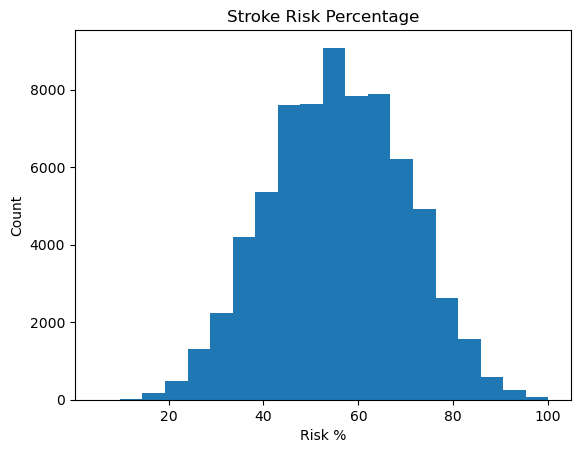

In [99]:
plt.hist(df3['stroke_risk_%'], bins=20)
plt.title("Stroke Risk Percentage")
plt.xlabel("Risk %")
plt.ylabel("Count")
plt.show()

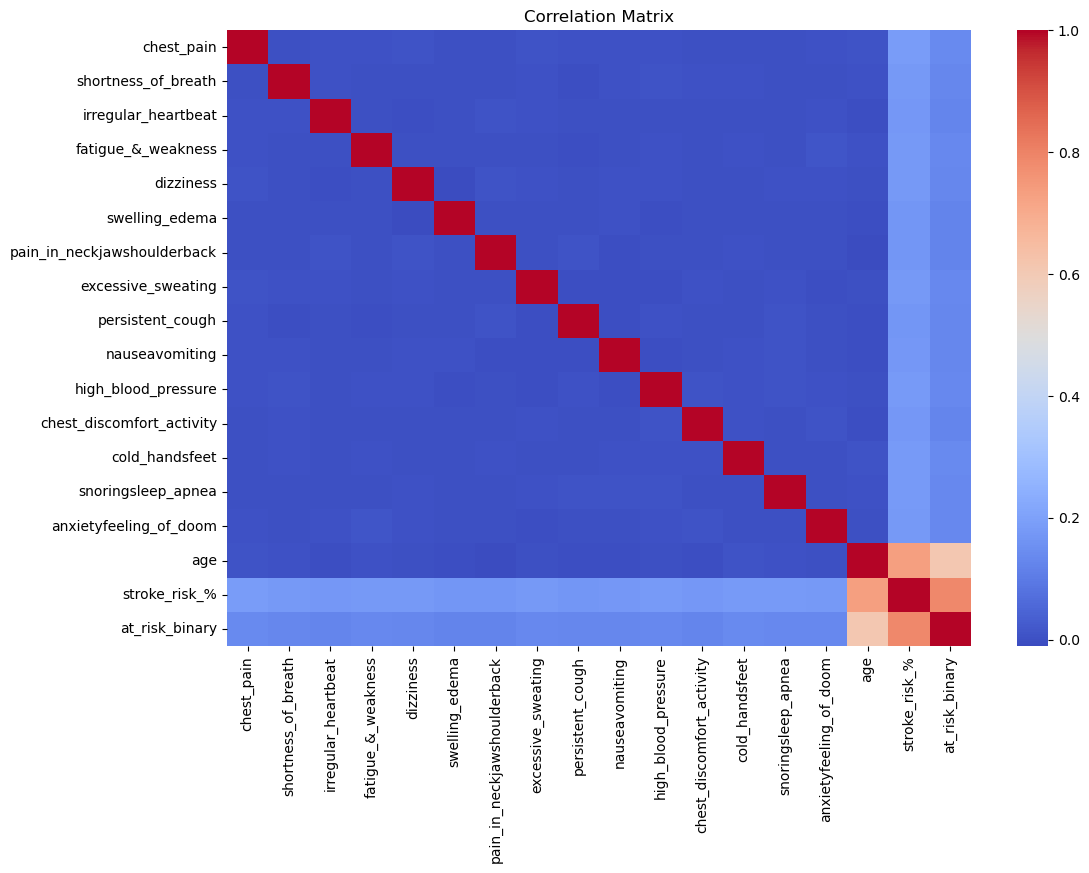

In [100]:
plt.figure(figsize=(12,8))
sns.heatmap(df3.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

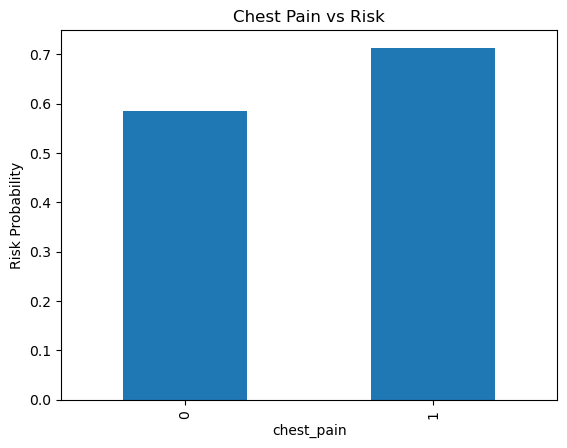

In [101]:
df3.groupby('chest_pain')['at_risk_binary'].mean().plot(kind='bar')
plt.title("Chest Pain vs Risk")
plt.ylabel("Risk Probability")
plt.show()

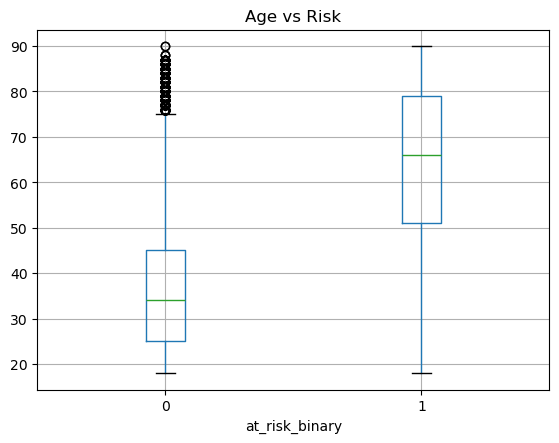

In [102]:
df3.boxplot(column='age', by='at_risk_binary')
plt.title("Age vs Risk")
plt.suptitle("")
plt.show()

In [103]:
corr = df3.corr()['at_risk_binary'].sort_values(ascending=False)
print(corr)

at_risk_binary                 1.000000
stroke_risk_%                  0.790743
age                            0.612038
cold_handsfeet                 0.136642
chest_pain                     0.135365
snoringsleep_apnea             0.133681
fatigue_&_weakness             0.133060
excessive_sweating             0.132806
high_blood_pressure            0.132301
anxietyfeeling_of_doom         0.131466
shortness_of_breath            0.130482
dizziness                      0.130444
persistent_cough               0.128700
nauseavomiting                 0.128645
irregular_heartbeat            0.124150
chest_discomfort_activity      0.123640
swelling_edema                 0.122416
pain_in_neckjawshoulderback    0.120280
Name: at_risk_binary, dtype: float64


In [104]:
df3.drop(['id'], axis=1, inplace=True, errors='ignore')

In [107]:
le = LabelEncoder()
for col in df3.select_dtypes(include='object'):
    df3[col] = le.fit_transform(df3[col])

In [111]:
top_features = [
    'age',
    'chest_pain',
    'high_blood_pressure',
    'shortness_of_breath',
    'dizziness',
    'irregular_heartbeat',
    'fatigue_&_weakness',
    'snoringsleep_apnea',
    'cold_handsfeet',
    'excessive_sweating',
    'persistent_cough',
    'swelling_edema'
]

In [112]:
X = df3[top_features]
y = df3['at_risk_binary']

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [114]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [135]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

model.fit(X_train, y_train)

D:\ml\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:08:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [136]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}
for name, model in models.items():
    model.fit(X_train, y_train)

D:\ml\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:11:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [137]:

results = []

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

In [120]:
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.894714   0.942602  0.892512  0.916873
1        Random Forest  0.876929   0.914934  0.893939  0.904315
2                  SVM  0.890714   0.942744  0.885815  0.913393
3        Decision Tree  0.854571   0.901544  0.871651  0.886346
4              XGBoost  0.900143   0.932951  0.912055  0.922385


In [125]:
final_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=7,
    n_estimators=200,
    use_label_encoder=False,
    eval_metric='logloss'
)

final_model.fit(X_train, y_train)

D:\ml\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:55:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [122]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

grid = GridSearchCV(XGBClassifier(), params, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


In [127]:
a=accuracy_score(y_test, y_pred)
print(a)
y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred))

0.8997142857142857
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      4892
           1       0.93      0.91      0.92      9108

    accuracy                           0.90     14000
   macro avg       0.89      0.90      0.89     14000
weighted avg       0.90      0.90      0.90     14000



In [128]:
y_prob = final_model.predict_proba(X_test)[:,1]

# Lower threshold from 0.5 → 0.4
y_pred = (y_prob > 0.4).astype(int)

In [138]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('model', XGBClassifier(
        learning_rate=0.1,
        max_depth=7,
        n_estimators=200,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

pipeline.fit(X_train, y_train)

D:\ml\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:31:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [140]:
print(type(pipeline))

<class 'imblearn.pipeline.Pipeline'>


AUC Score: 0.966464556241788


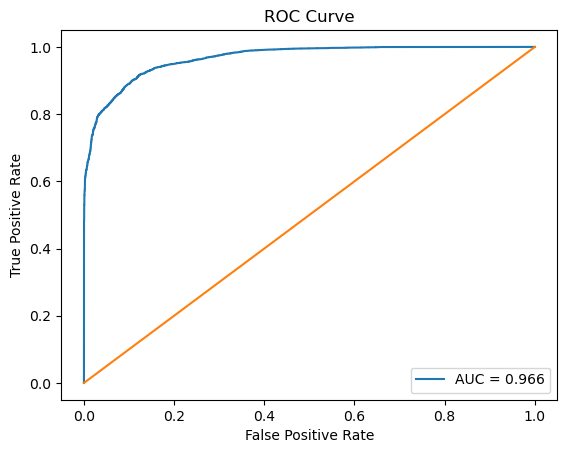

In [142]:
y_prob = pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1])  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

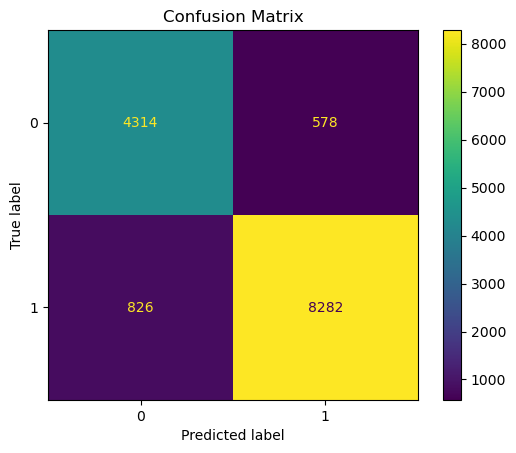

In [143]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [148]:
y_pred = pipeline.predict(X_test)

comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison_df.head(20))

    Actual  Predicted
0        1          1
1        0          0
2        0          0
3        0          0
4        1          1
5        0          0
6        1          1
7        1          0
8        0          1
9        0          1
10       0          0
11       0          0
12       0          0
13       0          0
14       1          1
15       1          1
16       1          1
17       1          1
18       0          0
19       1          1


In [150]:
comparison_df['Result'] = comparison_df['Actual'] == comparison_df['Predicted']
print(comparison_df.head(20))

    Actual  Predicted  Result
0        1          1    True
1        0          0    True
2        0          0    True
3        0          0    True
4        1          1    True
5        0          0    True
6        1          1    True
7        1          0   False
8        0          1   False
9        0          1   False
10       0          0    True
11       0          0    True
12       0          0    True
13       0          0    True
14       1          1    True
15       1          1    True
16       1          1    True
17       1          1    True
18       0          0    True
19       1          1    True


In [151]:
print(comparison_df['Result'].value_counts())

Result
True     12596
False     1404
Name: count, dtype: int64


In [153]:
with open("stroke_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

In [155]:
with open("stroke_pipeline.pkl", "rb") as f:
    loaded_pipeline = pickle.load(f)

In [156]:
y_pred = loaded_pipeline.predict(X_test)
print(y_pred[:10])

[1 0 0 0 1 0 1 0 1 1]
